In [1]:
import pyttb as ttb
import numpy as np

import goated.utils.exo as ex
import goated.utils.scalers as sc
import goated.goals.physics as goals

import goated.rol_interface.models as rolm
from goated.tucker import GotchaObjective, TuckerGoals

In [2]:
# Exodus file name with tensor data
fname = '../goated/examples/small.exo'

do_goal_plots = True  # construct goal plots
save_figs = False     # save figures
hosvd_tol = 0.25      # HOSVD tolerance for initial guess

In [3]:
# Read tensor from exodus file
exo = ex.ExoInfo()
exo.read_sheet(fname)
time = exo.t
num_time = len(time)

# Some global parameters
vars = [0,1,3,4,6,7,9]       # Exclude BZ, R, RHO_UZ, and U
B_var_ind = [0,1]            # variable indices for magnetic field
rho_var_ind = [2]            # variable index for density
mom_var_ind = [4,5]          # variables for momentum goal
T_var_ind = [6]              # variable index for temperature
tot_var_ind = B_var_ind+rho_var_ind+mom_var_ind+T_var_ind
int_var_ind = rho_var_ind+T_var_ind
kin_var_ind = rho_var_ind +mom_var_ind
mom_time_ind = range(1,num_time)    # time steps for momenum goal (exclude first few)
energy_time_ind = range(0,num_time) # time steps for energy goals

# select subset of variables
X = ttb.tensor(exo.tensor_data[:,:,vars,:])
sz = X.shape
var_labels = [exo.var_name[v] for v in vars]
# scale tensor values so that each variable has roughly the same order of magnitude
scaler = sc.StdScaler(X,exo.var_mode)
Xs = scaler.scale_tensor(X)

In [4]:
us0 = ttb.hosvd(Xs, hosvd_tol, verbosity=1)
U0 = scaler.unscale_tensor(us0.full())
fit0 = 1-(X-U0).norm()/X.norm()
print(f'Core size : {np.prod(us0.core.shape)}')

Computing HOSVD...

Shape of core: (5, 7, 5, 3)
||X-T||/||X|| =  0.148236 <= 0.250000 (tol)
Core size : 525


findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


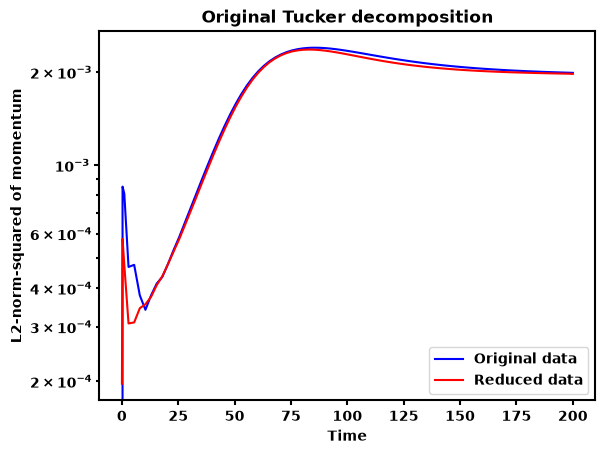

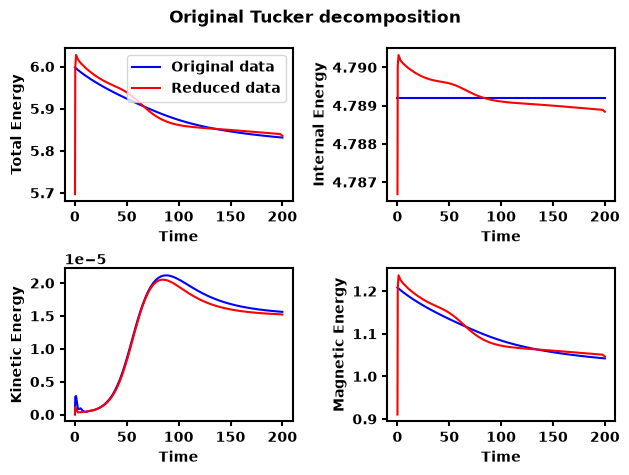

In [5]:
if do_goal_plots:
    fig,ax = goals.plot_momentum(X,us0,mom_var_ind,None,time,exo,scaler)
    ax.set_title('Original Tucker decomposition', fontweight='bold')
    if save_figs:
        fig.savefig('mom-initial.png')

    fig,axs = goals.plot_energies(X,us0,rho_var_ind,T_var_ind,mom_var_ind,B_var_ind,None,time,exo,scaler)
    fig.suptitle('Original Tucker decomposition', fontweight='bold')
    if save_figs:
        fig.savefig('energy-initial.png')

In [6]:
mom_goal = goals.MomentumGoal(X,mom_var_ind,mom_time_ind,exo)
E_goal = goals.TotalEnergyGoal(X,tot_var_ind,energy_time_ind,exo)
T_goal = goals.InternalEnergyGoal(X,int_var_ind,energy_time_ind,exo)
P_goal = goals.KineticEnergyGoal(X,kin_var_ind,energy_time_ind,exo)
B_goal = goals.MagneticEnergyGoal(X,B_var_ind,energy_time_ind,exo)

mom_goal0 = mom_goal.computeScalar(U0)
E_goal0 = E_goal.computeScalar(U0)
T_goal0 = T_goal.computeScalar(U0)
P_goal0 = P_goal.computeScalar(U0)
B_goal0 = B_goal.computeScalar(U0)

print(f'Initial fit = {fit0:.4f},\nmomentum goal = {mom_goal0:.2e},\ntotal energy goal = {E_goal0:.2e},\ninternal energy goal = {T_goal0:.2e},\nkinetic energy goal {P_goal0:.2e},\nmagnetic energy goal = {B_goal0:.2e}')

Initial fit = 0.9979,
momentum goal = 3.58e-07,
total energy goal = 1.01e-01,
internal energy goal = 1.82e-05,
kinetic energy goal 4.39e-11,
magnetic energy goal = 9.89e-02


In [7]:
my_goals = [mom_goal,T_goal,P_goal,B_goal]
ng = len(my_goals)+1
weights = [1/(ng*mom_goal0),1/(ng*T_goal0),1/(ng*P_goal0),1/(ng*B_goal0)]
a = 1/(ng*((Xs-us0.full()).norm()**2))
goals_obj = TuckerGoals(scaler, my_goals, weights)
gotcha = GotchaObjective(Xs, goals_obj, a, 1.0, jacobi=True)
precondition = True
rol_params = rolm.build_parameter_list(status_test_iter_limit=5)
problem = rolm.GoatedRolModel(gotcha, us0)
problem.solve(rol_params,precondition=precondition)



Truncated CG Trust-Region Solver
  iter  value          gnorm          snorm          delta          #fval     #grad     tr_flag   iterCG    flagCG    
  0     1.000000e+00   1.016856e+02   ---            1.000000e+01   1         1         ---       ---       ---       
  1     2.240751e-01   1.337157e+02   1.090727e+00   2.500000e+01   2         2         0         28        0         
  2     2.151880e-01   9.640640e+01   3.703822e-01   2.500000e+01   3         3         0         27        0         
  3     2.094722e-01   9.844228e-01   6.049132e-02   6.250000e+01   4         4         0         26        0         
  4     2.094489e-01   3.017477e+00   6.225512e-02   6.250000e+01   5         5         0         25        0         
  5     2.094364e-01   6.683424e-02   1.174686e-02   6.250000e+01   6         6         0         24        0         
Optimization Terminated with Status: Iteration Limit Exceeded


In [8]:
us1 = problem.decomp
U1 = scaler.unscale_tensor(us1.full())
fit1 = 1-(X-U1).norm()/X.norm()
mom_goal1 = mom_goal.computeScalar(U1)
E_goal1 = E_goal.computeScalar(U1)
T_goal1 = T_goal.computeScalar(U1)
P_goal1 = P_goal.computeScalar(U1)
B_goal1 = B_goal.computeScalar(U1)

print(f'Final fit = {fit1:.4f},\nmomentum goal = {mom_goal1:.2e},\ntotal energy goal = {E_goal1:.2e},\ninternal energy goal = {T_goal1:.2e},\nkinetic energy goal {P_goal1:.2e},\nmagnetic energy goal = {B_goal1:.2e}')

Final fit = 0.9976,
momentum goal = 4.48e-10,
total energy goal = 7.13e-04,
internal energy goal = 2.13e-07,
kinetic energy goal 3.04e-13,
magnetic energy goal = 7.38e-04


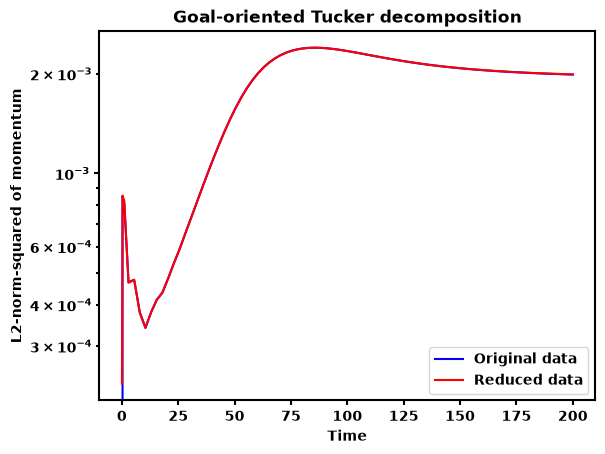

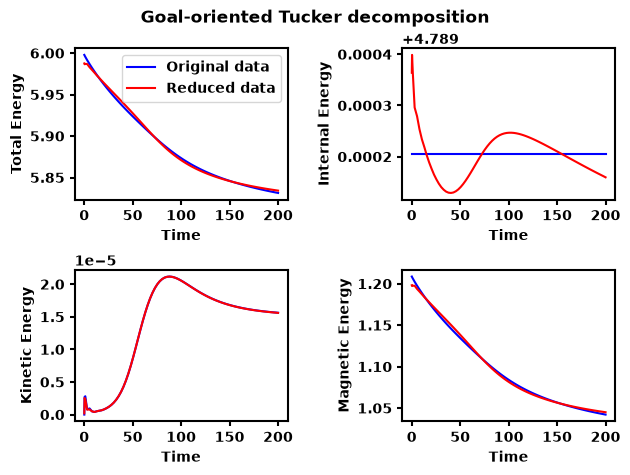

In [9]:
if do_goal_plots:
    fig,ax = goals.plot_momentum(X,us1,mom_var_ind,None,time,exo,scaler)
    ax.set_title('Goal-oriented Tucker decomposition',fontweight='bold')
    if save_figs:
        fig.savefig('mom-final.png')

    fig,axs = goals.plot_energies(X,us1,rho_var_ind,T_var_ind,mom_var_ind,B_var_ind,None,time,exo,scaler)
    fig.suptitle('Goal-oriented Tucker decomposition',fontweight='bold')
    if save_figs:
        fig.savefig('energy-final.png')